# 전력 센서 진단 (power_01 / watt)

`ttm_baseline_v2.ipynb`를 전력 검증으로 확장하기 전에 데이터 분포부터 확인합니다.

## 목적
1. 데이터 모양 확인 (분포, 시간 흐름)
2. CAUTION/DANGER 임계 후보 도출
3. spike 후보 시점 탐색

## 실행 후
마지막 셀이 추천 임계값을 출력합니다. 그 값을 메인 노트북 셀 1에 그대로 반영하시면 됩니다.

## 0. 라이브러리

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## 1. 데이터 로드 (3개 전력 센서 모두)

In [2]:
DB_PATH = '../SenSa/db.sqlite3'

con = sqlite3.connect(DB_PATH)
power_all = pd.read_sql_query('''
    SELECT d.device_id, s.timestamp, s.watt, s.current, s.voltage
    FROM devices_sensordata s
    JOIN devices_device d ON d.id = s.device_id
    WHERE d.sensor_type = 'power' AND s.watt IS NOT NULL
    ORDER BY s.timestamp ASC
''', con, parse_dates=['timestamp'])
con.close()

print(f'total rows:  {len(power_all)}')
print(f'devices:     {power_all["device_id"].unique().tolist()}')
print(f'time range:  {power_all["timestamp"].min()} ~ {power_all["timestamp"].max()}')
power_all.head()

total rows:  25525
devices:     ['power_01', 'power_02', 'power_03']
time range:  2026-04-27 06:24:45.293428 ~ 2026-05-06 06:02:34.625371


,device_id,timestamp,watt,current,voltage
0,power_01,2026-04-27 06:24:45.293428,2490.9,11.30,220.36
1,power_02,2026-04-27 06:24:45.313037,2563.2,11.75,218.18
2,power_03,2026-04-27 06:24:45.314739,2495.4,11.37,219.39
3,power_03,2026-04-27 06:24:46.754639,2570.3,11.61,221.46
4,power_02,2026-04-27 06:24:46.756651,2762.2,12.60,219.22


## 2. power_01 단일 센서로 분석

In [3]:
df = power_all[power_all['device_id']=='power_01'].copy().reset_index(drop=True)
print(f'power_01 rows: {len(df)}')

# 기본 통계
print('\n── watt 기본 통계 ──')
print(df['watt'].describe())

# percentile
pcts = [50, 75, 90, 95, 97, 99, 99.5, 99.9]
print('\n── percentiles ──')
for p in pcts:
    print(f'  P{p:>4}:  {np.percentile(df["watt"], p):.2f}')

power_01 rows: 8509

── watt 기본 통계 ──
count    8509.000000
mean     2773.203302
std       447.841397
min      1643.900000
25%      2501.900000
50%      2730.000000
75%      2985.000000
max      8593.900000
Name: watt, dtype: float64

── percentiles ──
  P  50:  2730.00
  P  75:  2985.00
  P  90:  3247.52
  P  95:  3426.00
  P  97:  3554.68
  P  99:  3878.03
  P99.5:  4532.34
  P99.9:  7090.15


## 3. 시계열 시각화
전체 흐름에서 spike·이상 구간 위치 파악.

/tmp/ipykernel_53037/2095163631.py:19: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_53037/2095163631.py:19: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/normalframe1094/SenSa/ai_lab/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/normalframe1094/SenSa/ai_lab/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


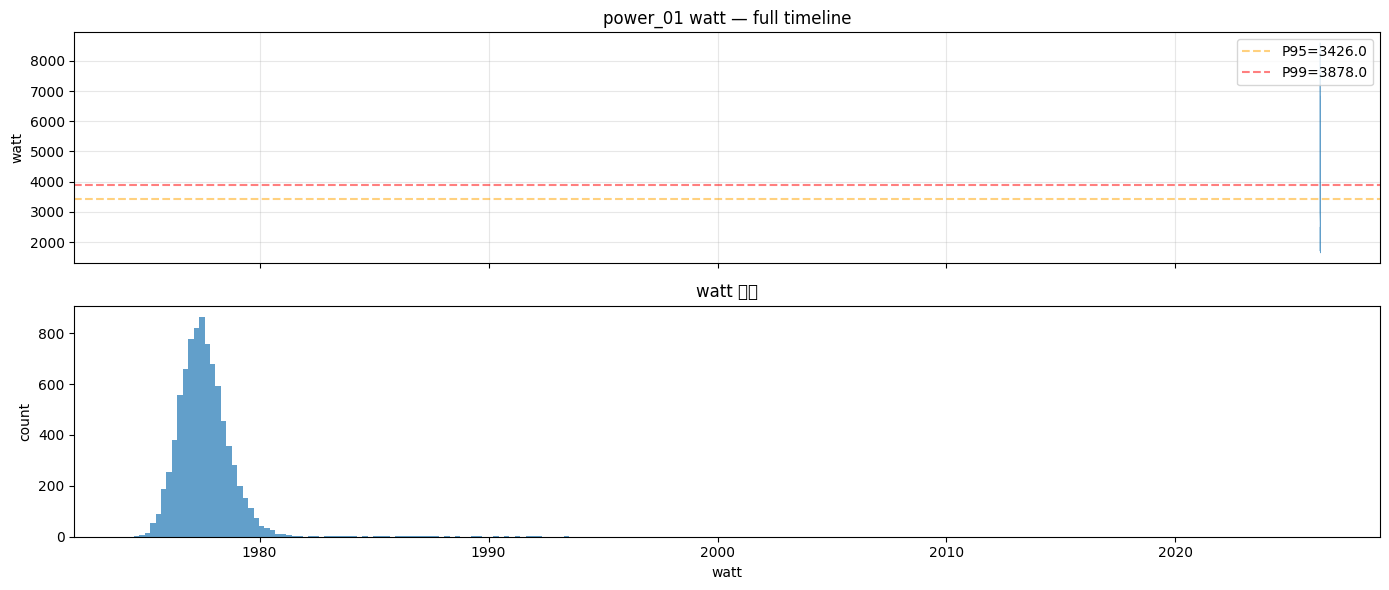

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df['timestamp'], df['watt'], color='#1f77b4', alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('watt')
axes[0].set_title('power_01 watt — full timeline')
axes[0].grid(True, alpha=0.3)

# 상위 percentile 라인
for p, color in [(95, 'orange'), (99, 'red')]:
    val = np.percentile(df['watt'], p)
    axes[0].axhline(val, color=color, ls='--', alpha=0.5, label=f'P{p}={val:.1f}')
axes[0].legend(loc='upper right')

# 분포 히스토그램
axes[1].hist(df['watt'], bins=80, color='#1f77b4', alpha=0.7)
axes[1].set_xlabel('watt'); axes[1].set_ylabel('count')
axes[1].set_title('watt 분포')

plt.tight_layout()
plt.show()

## 4. Spike 후보 시점 탐색

`P99` 이상 값이 처음 발생한 시점들 — TTM spike 검증용 후보.

In [5]:
P99 = np.percentile(df['watt'], 99)
high = df[df['watt'] >= P99].copy()

# 연속된 high 구간을 그룹핑 (5분 이내면 같은 이벤트로 묶음)
high['gap_min'] = high['timestamp'].diff().dt.total_seconds() / 60
high['event_id'] = (high['gap_min'] > 5).cumsum()

events = high.groupby('event_id').agg(
    start_time=('timestamp', 'min'),
    peak_value=('watt', 'max'),
    duration_min=('timestamp', lambda x: (x.max() - x.min()).total_seconds() / 60),
    count=('watt', 'size'),
).sort_values('peak_value', ascending=False)

print('상위 spike 후보 (P99 이상):')
print(events.head(10).to_string())

상위 spike 후보 (P99 이상):
                         start_time  peak_value  duration_min  count
event_id                                                            
1        2026-04-27 07:08:14.604075      8593.9      0.618794     23
0        2026-04-27 06:53:07.176169      8083.1      4.920222     21
14       2026-05-06 02:06:37.255543      6827.7      0.286166     12
9        2026-05-04 09:25:52.726035      4141.9      1.327441      4
10       2026-05-04 09:33:16.132066      4134.9      6.062703      9
6        2026-04-27 10:53:46.486659      4087.5      0.102077      2
13       2026-05-04 10:17:42.559350      4081.1      0.026236      2
4        2026-04-27 10:11:32.708288      4067.6      4.201515      2
11       2026-05-04 09:54:24.218083      4017.9      0.048605      3
8        2026-04-27 11:12:04.651848      3994.0      0.000000      1


## 5. 추천 임계값

메인 노트북 셀 1에 복사해서 넣을 값들.

In [6]:
# 임계값 도출
mean = df['watt'].mean()
std  = df['watt'].std()
p95  = np.percentile(df['watt'], 95)
p99  = np.percentile(df['watt'], 99)

# 추천 임계 (보수적 — 너무 자주 알람 안 뜨도록)
CAUTION_rec            = round(p95, 1)
DANGER_rec             = round(p99, 1)
RESIDUAL_ABS_LIMIT_rec = round(std * 5, 1)

# spike 후보 1순위
spike_recommend = events.head(1)['start_time'].iloc[0]

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  메인 노트북 셀 1 수정안')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f"DEVICE_ID  = 'power_01'")
print(f"METRIC     = 'watt'")
print()
print(f"CAUTION             = {CAUTION_rec}      # P95")
print(f"DANGER              = {DANGER_rec}      # P99")
print(f"RESIDUAL_ABS_LIMIT  = {RESIDUAL_ABS_LIMIT_rec}      # std × 5")
print()
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  메인 노트북 셀 9 (spike 검증) 시점')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f"start_time=pd.Timestamp('{spike_recommend}')")
print()
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  참고 통계')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'mean: {mean:.2f}   std: {std:.2f}   P95: {p95:.2f}   P99: {p99:.2f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  메인 노트북 셀 1 수정안
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEVICE_ID  = 'power_01'
METRIC     = 'watt'

CAUTION             = 3426.0      # P95
DANGER              = 3878.0      # P99
RESIDUAL_ABS_LIMIT  = 2239.2      # std × 5

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  메인 노트북 셀 9 (spike 검증) 시점
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
start_time=pd.Timestamp('2026-04-27 07:08:14.604075')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  참고 통계
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
mean: 2773.20   std: 447.84   P95: 3426.00   P99: 3878.03


## 다음 단계

1. 위 출력값을 메인 노트북(`ttm_baseline_v2.ipynb`) 셀 1에 반영
2. 셀 9의 `pd.Timestamp(...)`도 위에서 추천한 spike 시점으로 변경
3. 메인 노트북 `Kernel → Restart & Run All` 로 전력 검증 실행